# Trabalho Prático - Machine Learning
#### Aluna: Sarah Mariana Guedes de Almeida
##### 3º período - *Ciência de Dados*

> Este notebook apresenta os códigos referentes ao Trabalho Prático 1 (TP1) da disciplina Aprendizado de Máquina I, cujo objetivo é comparar diferentes métodos de classificação aplicados a um problema real de classificação binária.

> O problema consiste em classificar candidatos a exoplanetas identificados pela sonda espacial Kepler da NASA, utilizando os dados do arquivo *"koi_data.csv"*. A sonda detecta sinais de possíveis exoplanetas, chamados de Kepler Objects of Interest (KOI), mas nem todos os sinais correspondem a exoplanetas reais. Muitos, na verdade, são falsos positivos causados por fenômenos astronômicos diversos.

> Dessa forma, a tarefa é aprender a distinguir os KOIs confirmados como exoplanetas daqueles classificados como falsos positivos, com base em características extraídas de cada observação.

> Para isso, serão treinados e avaliados **seis métodos de classificação**: Naive Bayes, Decision Tree, k-Nearest Neighbors, Support Vector Machines, Random Forest e Gradient Tree Boosting.

> Cada método será analisado individualmente, com variação de hiperparâmetros quando aplicável, seguida de uma comparação geral entre os modelos ao final.

> A avaliação dos modelos será realizada por meio de validação cruzada k-fold com k = 5, utilizando métricas além da acurácia, de forma a capturar melhor o desempenho dos modelos diante da distribuição de classes presente nos dados.

> Todo o pré-processamento será aplicado dentro do processo de validação, por meio de pipelines, a fim de evitar vazamento de dados e garantir uma avaliação metodologicamente correta.

## Importações, leitura da base e análises iniciais do dataset

In [ ]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Lendo o CSV na pasta do Google Drive
# dkoi -> abreviação de Data Koi
dkoi = pd.read_csv('/content/drive/MyDrive/TP01/koi_data.csv')
dkoi

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5197,K08198.01,FALSE POSITIVE,373.89398,0.963,27.66000,730.0,0.03288,0.00771,2.51,0.8885,...,-1.000,-0.300,0.00060,0.00030,2.360,-0.990,2.550,2.370,-0.910,2.540
5198,K07984.01,FALSE POSITIVE,8.58987,0.765,4.80600,87.7,0.00936,0.18863,1.11,0.0779,...,1.100,1.200,-0.00008,-0.00010,1.260,-1.200,1.750,1.350,-1.300,1.840
5199,K07985.01,FALSE POSITIVE,0.52770,1.252,3.22210,1579.2,0.29763,0.16318,29.35,0.0128,...,0.792,-0.484,-0.00024,0.00018,2.132,-1.757,2.763,2.344,-1.756,2.929
5200,K07987.01,FALSE POSITIVE,0.68140,0.147,0.86500,103.6,0.00944,8.97692,1.07,0.0157,...,7.200,-5.600,-0.00072,0.00050,3.410,-3.650,5.000,3.380,-3.890,5.160


In [ ]:
# Verificando o Shape
dkoi.shape

(5202, 43)

In [ ]:
# Verificando as primeiras linhas
dkoi.head()

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948


> dkoi.shape nos mostra que o dataset possui 43 colunas e 5202 linhas.

In [ ]:
# Verificando tipos
dkoi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   object 
 1   koi_disposition   5202 non-null   object 
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_snr     5202 non-null   float64


In [ ]:
# Verificando valores faltantes por coluna
dkoi.isnull().sum()

,0
kepoi_name,0
koi_disposition,0
koi_period,0
koi_impact,0
koi_duration,0
koi_depth,0
koi_ror,0
koi_srho,0
koi_prad,0
koi_sma,0


> dkoi.info() nos mostra que a maioria das colunas é do tipo float, tirando as duas primeiras, que são do tipo object.

> Além disso, nos mostra que todas as linhas estão preenchidas, indicando que não existem valores nulos. A função dkoi.isnull().sum() confirma isso, pois a saída é 0 em todas as 43 colunas.

In [ ]:
# Verificando quantas linhas são confirmadas como exoplaneta
dkoi[dkoi['koi_disposition'] == 'CONFIRMED']

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.4300,0.9400,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.31,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.6300,1.2300,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.12,0.500
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.0100,0.2300,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.02,0.070
5,K00757.01,CONFIRMED,16.06865,0.052,3.53470,4914.3,0.06216,3.66590,5.76,0.1158,...,0.0330,-0.0440,0.00026,0.00049,0.041,-0.015,0.044,0.005,0.03,0.031
6,K00001.01,CONFIRMED,2.47061,0.818,1.74319,14231.0,0.12387,1.83538,13.04,0.0354,...,-0.0232,0.1066,-0.00012,0.00078,-0.009,-0.300,0.300,0.015,-0.27,0.270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4134,K02926.04,CONFIRMED,37.63339,0.338,4.49000,1661.7,0.03659,3.30110,2.25,0.1861,...,-0.7300,0.8100,0.00110,-0.00190,0.190,0.150,0.250,-0.020,0.00,0.020
4135,K03371.02,CONFIRMED,12.25384,0.441,2.37300,147.7,0.01122,5.83094,1.00,0.1016,...,0.6000,-0.3800,-0.00005,0.00005,0.000,-0.720,0.720,0.100,-0.65,0.660
4144,K00351.07,CONFIRMED,124.92252,0.943,11.94200,498.7,0.02574,0.04072,3.37,0.5036,...,0.7000,0.3600,-0.00037,-0.00014,-0.240,-0.010,0.240,-0.240,-0.04,0.250
4879,K07016.01,CONFIRMED,384.84756,0.059,9.96900,189.9,0.01249,3.38283,1.09,0.9940,...,2.0000,1.9000,-0.00033,-0.00029,-1.140,1.250,1.690,-1.000,1.36,1.690


In [ ]:
# Verificando quantas linhas são falsos positivos
dkoi[dkoi['koi_disposition'] == 'FALSE POSITIVE']

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.1110,0.0020,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.4500,24.0900,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948
9,K00742.01,FALSE POSITIVE,11.52145,2.483,3.63990,17984.0,1.62536,1.27376,150.51,0.0978,...,0.0680,-0.0380,0.00000,0.00010,0.009,-0.009,0.013,0.147,0.037,0.151
10,K00743.01,FALSE POSITIVE,19.40394,0.804,12.21550,8918.7,0.09673,0.03785,7.18,0.1230,...,0.0380,-0.0050,-0.00038,-0.00020,-0.001,0.009,0.009,-0.147,-0.038,0.152
11,K00744.01,FALSE POSITIVE,19.22139,1.065,4.79843,74284.0,0.47663,1.57359,49.29,0.1417,...,-0.1235,-0.2667,-0.00050,-0.00200,0.003,0.005,0.006,-0.018,-0.203,0.203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5197,K08198.01,FALSE POSITIVE,373.89398,0.963,27.66000,730.0,0.03288,0.00771,2.51,0.8885,...,-1.0000,-0.3000,0.00060,0.00030,2.360,-0.990,2.550,2.370,-0.910,2.540
5198,K07984.01,FALSE POSITIVE,8.58987,0.765,4.80600,87.7,0.00936,0.18863,1.11,0.0779,...,1.1000,1.2000,-0.00008,-0.00010,1.260,-1.200,1.750,1.350,-1.300,1.840
5199,K07985.01,FALSE POSITIVE,0.52770,1.252,3.22210,1579.2,0.29763,0.16318,29.35,0.0128,...,0.7920,-0.4840,-0.00024,0.00018,2.132,-1.757,2.763,2.344,-1.756,2.929
5200,K07987.01,FALSE POSITIVE,0.68140,0.147,0.86500,103.6,0.00944,8.97692,1.07,0.0157,...,7.2000,-5.6000,-0.00072,0.00050,3.410,-3.650,5.000,3.380,-3.890,5.160


> Com isso, podemos ver que a maioria das linhas são falsos positivos (3098) e apenas 2104 são confirmados.

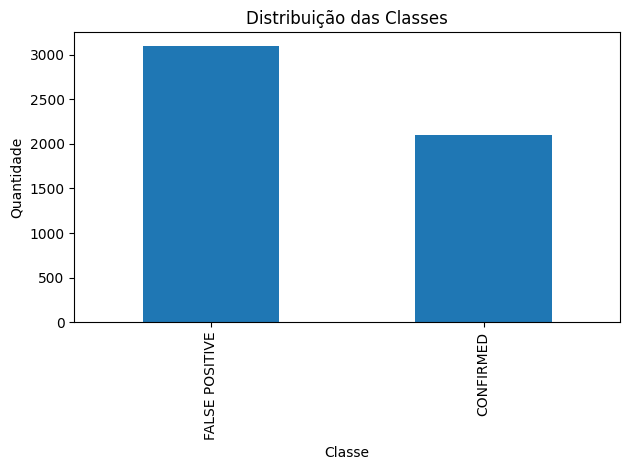

In [ ]:
# Mostrar essa distribuição de forma mais visual
dkoi['koi_disposition'].value_counts().plot(kind='bar')
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

In [ ]:
# Proporção em porcentagem
dkoi['koi_disposition'].value_counts(normalize=True) * 100
# normalize = True instrui o value counts a retornar o percentual

,proportion
koi_disposition,
FALSE POSITIVE,59.554018
CONFIRMED,40.445982


> Assim, temos que aproximadamente 59.55% do dataset é constituido por Falsos Positivos, e aproximadamente 40.45% representa casos confirmados.

> É um desbalanceamento leve, considerando a proporção quase igual a 60/40. Apesar disso, ele tem implicações importantes para a avaliação dos modelos.

> Um modelo que classificasse todos os exemplos como falso positivo atingiria 60% de acurácia sem aprender nenhum padrão real nos dados. Por isso, a acurácia sozinha não é suficiente como métrica de avaliação.

>Ao longo deste trabalho, serão utilizadas também precisão, recall e F1-score para avaliar os modelos de forma mais completa.

## Separando X e Y

In [ ]:
# Separando X (matriz de features) e Y (vetor de rótulos, ou seja, a resposta correta)
# Temos que remover a coluna kepoi_name, pois é um ID e não serve para o modelo.
# A coluna koi_disposition tem que ser removida, pois é o nosso rótulo, não podendo estar dentro das features.
X = dkoi.drop(columns=['kepoi_name', 'koi_disposition'])
y = dkoi['koi_disposition']


In [ ]:
X.shape

(5202, 41)

In [ ]:
y.shape

(5202,)

In [ ]:
# Confirmando se foram apagadas
X.columns.tolist()

['koi_period',
 'koi_impact',
 'koi_duration',
 'koi_depth',
 'koi_ror',
 'koi_srho',
 'koi_prad',
 'koi_sma',
 'koi_incl',
 'koi_teq',
 'koi_insol',
 'koi_dor',
 'koi_max_sngle_ev',
 'koi_max_mult_ev',
 'koi_model_snr',
 'koi_steff',
 'koi_slogg',
 'koi_smet',
 'koi_srad',
 'koi_smass',
 'koi_kepmag',
 'koi_gmag',
 'koi_rmag',
 'koi_imag',
 'koi_zmag',
 'koi_jmag',
 'koi_hmag',
 'koi_kmag',
 'koi_fwm_stat_sig',
 'koi_fwm_sra',
 'koi_fwm_sdec',
 'koi_fwm_srao',
 'koi_fwm_sdeco',
 'koi_fwm_prao',
 'koi_fwm_pdeco',
 'koi_dicco_mra',
 'koi_dicco_mdec',
 'koi_dicco_msky',
 'koi_dikco_mra',
 'koi_dikco_mdec',
 'koi_dikco_msky']

> Como é um modelo supervisionado, aqui definimos e separamos o X e Y.

> O X representa a ***matriz de features***, ou seja, as informações que o modelo vai utilizar para aprender o problema. No contexto, serão 41 colunas, que representam as características específicas dos candidatos a exoplaneta. O .drop foi feito para remover o 'kepoi_name', um ID do exoplaneta, que não funciona para modelos de machine learning.
'koi_disposition' foi removido do X, pois ele representa o Y. *Precisa ser removido para não ter vazamento de dados.*

> O Y representa o nosso ***rótulo***, o que queremos classificar (casos confirmados e falsos positivos). É a resposta correta de cada exemplo.

## Configuração da Validação Cruzada

>  Para avaliar o desempenho dos modelos de classificação, será utilizada a técnica de validação cruzada **k-fold com k = 5**.

> Nessa abordagem, o conjunto de dados é dividido em cinco subconjuntos de tamanho aproximadamente igual. Em cada iteração, quatro subconjuntos são utilizados para treinamento do modelo e o subconjunto restante é utilizado para validação. O processo é repetido cinco vezes, alternando o subconjunto de validação, e ao final é calculada a **média dos resultados obtidos.**

> Será utilizada a estratégia **Stratified K-Fold Cross Validation** da biblioteca 'sklearn': essa abordagem mantém a proporção das classes em cada divisão dos dados, proporcionando uma avaliação mais estável e confiável dos modelos, especialmente em conjuntos com leve desbalanceamento entre as classes (60/40, como vimos anteriormente).

In [ ]:
# Importando a biblioteca e a estratégia de validação
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Atribuindo variavel
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

> Definimos a função estratégia de validação com três parâmetros:

`n_splits = 5`

> Define que os dados serão divididos em cinco partes (folds). Em cada iteração, quatro partes são utilizadas para treinamento e uma para validação. Esse processo é repetido cinco vezes, alternando o conjunto de validação.

`shuffle = True`

> Mistura os dados antes de dividir, evitando viés da ordem original do dataset, garantindo uma distribuição mais representativa.

`random_state = 42`

> Define uma semente aleatória fixa, garantindo que a divisão dos dados seja reproduzível e permitindo que os dados possam ser replicados.

## Métricas de avaliação

> Para avaliar o desempenho dos modelos, serão utilizadas múltiplas métricas, de forma a obter uma análise mais completa dos resultados. **Além da acurácia**, também serão utilizadas **precisão, recall e F1-score**.

> **Acurácia**: mede a proporção de classificações corretas no conjunto de dados, mas como existe um leve desbalanceamento, não é suficiente nesse caso.

> **Precisão**: mede a proporção de previsões positivas corretas.

> **Recall**: mede a capacidade do modelo de identificar corretamente os exemplos positivos.

> **F1-score**: combina precisão e recall, fornecendo uma medida equilibrada entre ambas.

O uso dessas métricas permite avaliar diferentes aspectos do desempenho dos modelos, possibilitando uma comparação mais robusta entre eles.

In [ ]:
# Importando as métricas do scikit learn
# make_scorer precisa ser importado para transformar uma métrica em um formato que o scikit-learn consegue usar quando chegarmos na validação cruzada
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Pré-Processamento dos Dados
> Para manter consistência na comparação dos modelos, que possuem diferentes níveis de sensibilidade às escalas dos dados, será aplicada a **padronização dos dados**.

> Assim, será utilizado o StandardScaler, por ser uma abordagem mais robusta à presença de outliers, e tende a apresentar melhor desempenho em algoritmos sensíveis à escalas das variáveis, como SVM e KNN, garantindo uma comparação mais consistente entre os modelos.

In [ ]:
# Importando o StandardScaler e Pipeline para juntar etapas futuramente
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Criando o modelo Naive Bayes
> Iniciaremos com o algoritmo Naive Bayes. Esse modelo será utilizado como baseline, servindo como referência inicial para comparação com os demais métodos.


In [ ]:
dkoi.describe()

,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,koi_teq,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
count,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,...,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000
mean,37.032237,0.717106,5.607025,21340.318993,0.235205,3.415370,112.230798,0.158146,81.181413,1143.721069,...,-0.355681,-0.805629,-0.000263,0.000439,-0.049743,-0.087413,1.930251,-0.038402,-0.098738,1.920226
std,88.417985,2.628207,6.962634,66989.808550,2.586213,25.131368,3699.799318,0.241792,16.308839,775.788868,...,10.978677,14.741473,0.065707,0.077519,2.465670,2.746534,3.147553,2.465094,2.734732,3.142764
min,0.306940,0.000000,0.104600,0.800000,0.001290,0.000040,0.080000,0.007200,2.290000,92.000000,...,-275.600000,-397.620000,-4.000000,-0.800000,-21.500000,-75.900000,0.000000,-23.600000,-76.600000,0.000000
25%,2.213963,0.226000,2.500250,176.800000,0.013057,0.176092,1.460000,0.033000,81.930000,615.250000,...,-0.500000,-0.570000,-0.000240,-0.000240,-0.270000,-0.291500,0.128250,-0.265250,-0.320000,0.180000
50%,7.386755,0.610000,3.805500,495.950000,0.024185,0.748045,2.600000,0.073650,87.890000,948.000000,...,0.000000,-0.030000,0.000000,0.000000,0.000000,0.000000,0.460000,-0.007000,-0.018000,0.453000
75%,23.448118,0.923750,6.000750,2120.525000,0.171260,2.267062,21.645000,0.158200,89.520000,1482.000000,...,0.500000,0.450000,0.000260,0.000280,0.230000,0.230000,2.570000,0.226250,0.250000,2.420000
max,1071.232620,100.806000,138.540000,864260.000000,99.870650,918.752390,200346.000000,2.034500,90.000000,9791.000000,...,97.780000,98.780000,1.190000,5.000000,45.680000,27.500000,88.600000,46.570000,31.200000,89.600000


In [ ]:
# Importando o Naive Bayes e o algoritmo GaussianNB (é uma implementação do Naive Bayes, utilizado para datasets com dados numéricos)
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Criando o molde do modelo, para depois treinar
naivebayes_model = GaussianNB()

In [ ]:
# Criando a pipeline para organização das etapas do treinamento (padronização -> treino), evitando data leakage
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', naivebayes_model)
])

### Aplicando validação cruzada

In [ ]:
# Importando a função de validação cruzada
from sklearn.model_selection import cross_validate # Essa função treina o modelo várias vezes e calcula métricas automaticamente

In [ ]:
# Definindo métricas que vimos anteriormente e utilizaremos para avaliar o modelo
# Definimos também que a classe positiva é 'CONFIRMED' no pos_label
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='CONFIRMED'),
    'recall': make_scorer(recall_score, pos_label='CONFIRMED'),
    'f1': make_scorer(f1_score, pos_label='CONFIRMED')
}

> Observação: como estamos fazendo uma classificação binária, consideramos a classe "CONFIRMED" como positiva, pois representa os exoplanetas confirmados, ou seja, o que queremos detectar corretamente na análise.

In [ ]:
# Validação Cruzada
resultados_nb = cross_validate(
    pipeline_nb,
    X,
    y,
    cv=skf,
    scoring=scoring
)

> Assim como vimos, a célula de validação cruzada faz:
divisão dos dados em 5 folds, depois treina e testa 5 vezes, calcula as 4 métricas e guarda tudo em uma variável chamada `resultados_nb` (nb é abreviação de Naive Bayes).


In [ ]:
# Vendo os resultados
resultados_nb

{'fit_time': array([0.02999759, 0.02252698, 0.02407074, 0.02171874, 0.02046537]),
 'score_time': array([0.04630661, 0.03452182, 0.04290748, 0.04493141, 0.03679729]),
 'test_accuracy': array([0.91738713, 0.92315082, 0.91346154, 0.90961538, 0.92307692]),
 'test_precision': array([0.85263158, 0.85154639, 0.84551148, 0.83435583, 0.84693878]),
 'test_recall': array([0.96199525, 0.98099762, 0.96199525, 0.96912114, 0.98809524]),
 'test_f1': array([0.90401786, 0.91169978, 0.9       , 0.8967033 , 0.91208791])}

In [ ]:
# Imprimindo os resultados
print("Média acurácia:", np.mean(resultados_nb['test_accuracy']))
print("Média precisão:", np.mean(resultados_nb['test_precision']))
print("Média recall:", np.mean(resultados_nb['test_recall']))
print("Média F1-Score:", np.mean(resultados_nb['test_f1']))

Média acurácia: 0.9173383580876375
Média precisão: 0.8461968113371412
Média recall: 0.9724409003506391
Média F1-Score: 0.9049017690367028


In [ ]:
pd.DataFrame(resultados_nb).mean()

,0
fit_time,0.023756
score_time,0.041093
test_accuracy,0.917338
test_precision,0.846197
test_recall,0.972441
test_f1,0.904902


### Interpretando os resultados
> O Naive Bayes é um modelo probabilístico baseado no teorema de Bayes que assume independência entre as features. Por não ser baseado em distâncias, não é sensível à escala dos dados e o `StandardScaler` não foi aplicado.

> O modelo atingiu acurácia de 91,7%, precisão de 84,6%, recall de 97,2% e F1-score de 90,5%. O recall muito elevado indica que o modelo raramente deixa de identificar um exoplaneta real, mas a precisão mais baixa revela uma tendência a gerar falsos positivos. Esse comportamento é esperado no Naive Bayes: a suposição de independência entre features raramente se verifica na prática, o que compromete a precisão do modelo.

> Como baseline, o Naive Bayes estabelece uma referência mínima de desempenho: qualquer modelo que não supere esses resultados não está aprendendo padrões relevantes nos dados.

## Criando o Modelo Decision Tree

> O próximo modelo será a Árvore de Decisão. Será analisado o desempenho da Decision Tree variando a altura máxima da árvore `(max_depth)`, incluindo a configuração sem limite, permitindo observar como esse hiperparâmetro influencia a capacidade preditiva e o possível overfitting do modelo.

In [ ]:
# Importando a Árvore de Decisão e definindo as alturas da árvore
from sklearn.tree import DecisionTreeClassifier

# Testaremos diferentes níveis de complexidade da árvore
max_depths = [2, 4, 6, 8, 10, 12, None]

resultados_dkoi = []

In [ ]:
# Criando o Loop de treino para cada modelo
# Iremos treinar uma árvore para cada max_depth, e executar a pipeline de novo
for depth in max_depths:

    pipeline_dkoi = Pipeline([
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    scores = cross_validate(
        pipeline_dkoi,
        X,
        y,
        cv=skf,
        scoring=scoring
    )

    resultados_dkoi.append(scores['test_f1'].mean())

In [ ]:
# Vendo resultados em uma tabela
dkoi_resultados_dkoi = pd.DataFrame({
    'max_depth': max_depths,
    'F1_score_medio': resultados_dkoi
})

dkoi_resultados_dkoi

,max_depth,F1_score_medio
0,2.0,0.850722
1,4.0,0.928749
2,6.0,0.938551
3,8.0,0.937124
4,10.0,0.937465
5,12.0,0.936574
6,NaN,0.931794


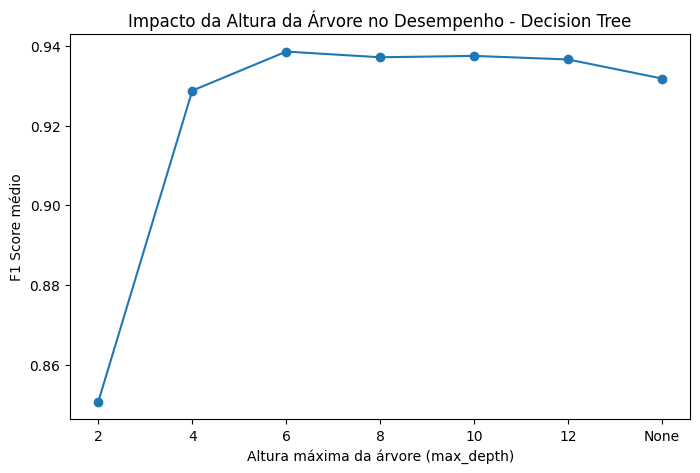

In [ ]:
# Visualizando os resultados

max_depths_plot = [str(d) for d in max_depths]

plt.figure(figsize=(8,5))
plt.plot(max_depths_plot, resultados_dkoi, marker='o')

plt.xlabel("Altura máxima da árvore (max_depth)")
plt.ylabel("F1 Score médio")
plt.title("Impacto da Altura da Árvore no Desempenho - Decision Tree")

plt.show()

### Interpretando os resultados

> A Decision Tree não é sensível à escala dos dados, pois toma decisões com base em limiares de corte nas features, e não em distâncias. Por isso, o uso do `StandardScaler` não foi aplicado neste modelo.

> Árvores com profundidade muito baixa, como `max_depth=2`, apresentaram desempenho inferior, indicando underfitting: a árvore não tem complexidade suficiente para capturar os padrões relevantes nos dados. No extremo oposto, a árvore sem limite `(max_depth=None)` apresentou leve queda de desempenho em relação ao melhor resultado, indicando início de overfitting, onde o modelo passa a memorizar ruídos do treino em vez de aprender padrões generalizáveis.

> Os resultados obtidos mostram que `max_depth=6` representou o melhor equilíbrio entre esses dois extremos, atingindo F1-score de aproximadamente 0.9385. Esses resultados ilustram o trade-off bias-variância: modelos muito simples têm alto bias e baixa variância, enquanto modelos muito complexos têm baixo bias mas alta variância. A escolha adequada da profundidade máxima é, portanto, fundamental para garantir boa capacidade de generalização do modelo.

### Modelo final da Árvore de Decisão

> Utilizaremos o melhor hiperparâmetro dos resultados obtidos na sessão anterior: `max_depth = 6` e F1 = 0.9385

In [ ]:
# Criando a pipeline final
pipeline_dkoi_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(max_depth=6, random_state=42))
])

In [ ]:
# Executando novamente a validação cruzada
resultados_dkoi_final = cross_validate(
    pipeline_dkoi_final,
    X,
    y,
    cv=skf,
    scoring=scoring
)

In [ ]:
# Calculando as médias
pd.DataFrame(resultados_dkoi_final).mean()

,0
fit_time,0.150265
score_time,0.022050
test_accuracy,0.949249
test_precision,0.919364
test_recall,0.958656
test_f1,0.938551


### Interpretando resultados finais

> Com base no experimento anterior, foi selecionado `max_depth=6` como hiperparâmetro final por ter apresentado o melhor equilíbrio entre bias e variância.

> O modelo final atingiu acurácia de aproximadamente 94,9%, precisão de 91,9%, recall de 95,9% e F1-score de 93,9%. O recall elevado indica que o modelo tem boa capacidade de identificar corretamente os exoplanetas confirmados, o que é especialmente relevante neste problema, onde classificar um exoplaneta real como falso positivo representa uma descoberta científica perdida.

## Criando o modelo Support Vector Machine (SVM)

> O SVM é um algoritmo que tenta encontrar uma fronteira de decisão que separe as duas classes com a maior margem possível. Nesse contexto, ele será avaliado com quatro kernels diferentes: **linear, sigmoid, polinomial e RBF**. Cada kernel define uma forma distinta de separar as classes no espaço de features, e o objetivo deste experimento é comparar o desempenho de cada um e entender como essa escolha afeta os resultados.

In [ ]:
# Importando SVC, a classe do SVM para classificação dentro do scikit-learn.
from sklearn.svm import SVC


In [ ]:
# Definindo os Kernels que serão recebidos como parâmetro no SVC
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
resultados_svm = {}

In [ ]:
# Iterando sobre os kernels usando StandardScaler para padronizar, SVC para treinar e por fim, fazer Validação cruzada
for kernel in kernels:
    pipeline_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel=kernel, random_state=42, max_iter=5000, cache_size=500))
    ])

    scores = cross_validate(
        pipeline_svm,
        X,
        y,
        cv=skf,
        scoring=scoring
    )

    resultados_svm[kernel] = {
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean()
    }

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

In [ ]:
# Visualizando os resultados de cada kernel
df_svm = pd.DataFrame(resultados_svm).T
print(df_svm)

         accuracy  precision    recall        f1
linear   0.951749   0.921769  0.962460  0.941627
rbf      0.935601   0.894459  0.953425  0.922951
poly     0.878508   0.779296  0.976715  0.866842
sigmoid  0.826989   0.780328  0.796593  0.788175


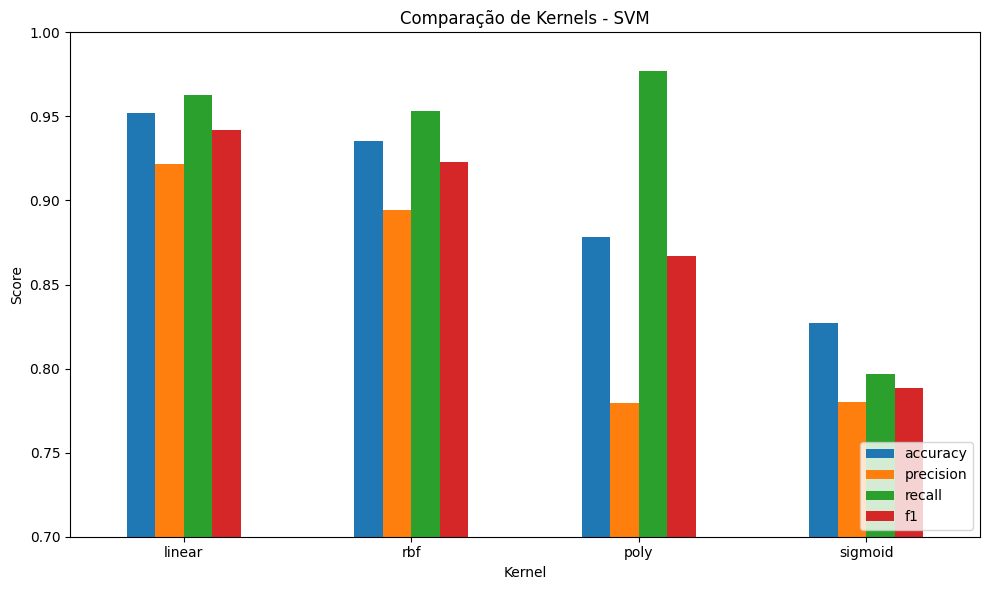

In [ ]:
# Gerando gráfico para melhor visualização
df_svm.plot(kind='bar', figsize=(10, 6))
plt.title('Comparação de Kernels - SVM')
plt.xlabel('Kernel')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

### Interpretando os resultados

> O kernel **linear** apresentou o melhor desempenho geral, com F1-score de 0.9416 e bom equilíbrio entre precisão e recall. Isso sugere que os dados, após a padronização, são aproximadamente linearmente separáveis no espaço original das features.

> O kernel **RBF** ficou em segundo lugar com F1-score de 0.9230, também apresentando bom equilíbrio entre as métricas.

> O kernel **polinomial** apresentou o recall mais alto de todos (0.9767), porém com precisão muito baixa (0.7793). Isso indica que o modelo tende a classificar excessivamente exemplos como `CONFIRMED`, gerando muitos falsos positivos. O F1-score de 0.8668 reflete esse desequilíbrio.

> O kernel **sigmoid** obteve o pior desempenho em todas as métricas, com F1-score de 0.7882. O kernel sigmoid frequentemente apresenta desempenho inferior em problemas de classificação em relação aos demais kernels. Além disso, tanto o sigmoid quanto o polinomial apresentaram avisos de não convergência, indicando que 5000 iterações não foram suficientes para que o otimizador encontrasse uma solução estável, o que pode ter impactado negativamente seus resultados.

> Com base nesses resultados, o kernel **linear** será utilizado como configuração final do SVM.

### Modelo final do Support Vector Machine

> Como foi observado, o kernel **linear** foi selecionado por ter apresentado o melhor equilíbrio entre precisão e recall, com F1-score de 0.9416.

In [ ]:
# Fazendo a pipeline final utilizando o kernel Linear
pipeline_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', random_state=42))
])

resultados_svm_final = cross_validate(
    pipeline_svm_final,
    X,
    y,
    cv=skf,
    scoring=scoring
)
# Fazendo a média
pd.DataFrame(resultados_svm_final).mean()

,0
fit_time,0.249977
score_time,0.047620
test_accuracy,0.951173
test_precision,0.921692
test_recall,0.961033
test_f1,0.940909


### Interpretação dos resultados finais

> O modelo final atingiu acurácia de aproximadamente 95,1%, precisão de 92,2%, recall de 96,1% e F1-score de 94,1%. O recall elevado indica que o modelo tem boa capacidade de identificar corretamente os exoplanetas confirmados, o que é especialmente relevante neste problema, onde classificar um exoplaneta real como falso positivo representa uma descoberta científica perdida.

## Criando o Modelo K-NN (K-Nearest Neighbors)

> O K-NN classifica um novo exemplo com base nos k vizinhos mais próximos no espaço de features, atribuindo a classe mais frequente entre eles. Neste experimento, o valor de k será variado de 1 a 30, com o objetivo de identificar o valor que melhor equilibra bias e variância. Como o algoritmo é baseado em distância, o `StandardScaler`, novamente, será aplicado dentro do pipeline para garantir que todas as features contribuam de forma proporcional.

In [ ]:
# Importando o algoritmo
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Testando o modelo k-NN para valores de k de 1 a 30, a cada iteração, um novo pipeline é criado com o StandardScaler e o KNeighborsClassifier
# O F1-score médio de cada k é armazenado na lista resultados_knn
k_values = range(1, 31)
resultados_knn = []

for k in k_values:
    pipeline_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        pipeline_knn,
        X,
        y,
        cv=skf,
        scoring=scoring
    )

    resultados_knn.append(scores['test_f1'].mean())

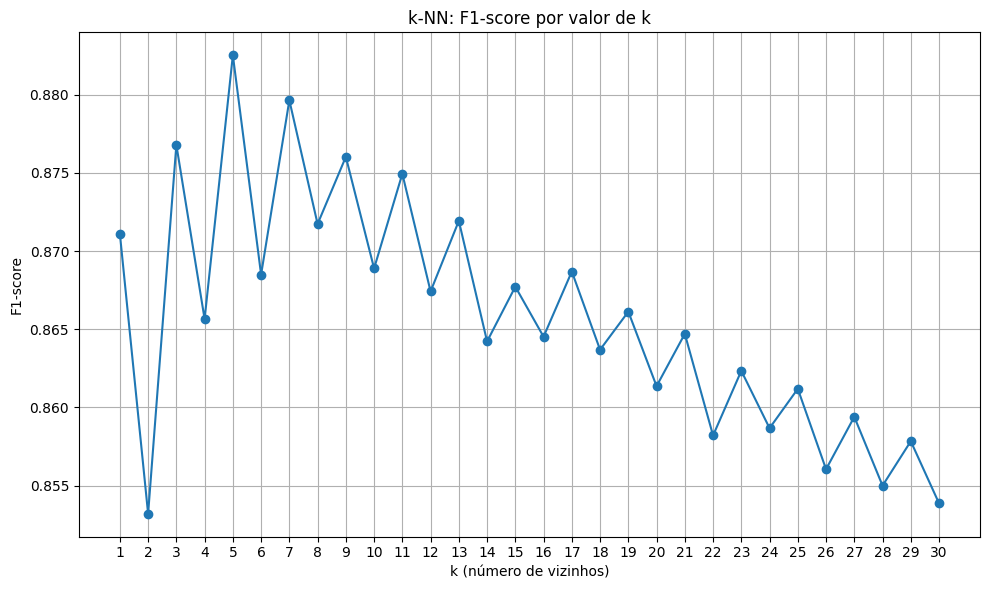

In [ ]:
# Visualizando resultados

plt.figure(figsize=(10, 6))
plt.plot(k_values, resultados_knn, marker='o')
plt.title('k-NN: F1-score por valor de k')
plt.xlabel('k (número de vizinhos)')
plt.ylabel('F1-score')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

> Observamos que k=2 foi o pior resultado, e k=5 foi o melhor.
A partir de k=5, há uma tendência geral de queda no desempenho conforme k aumenta, com algumas oscilações. Valores muito altos de k, como k=30, apresentam os piores resultados da faixa superior

In [ ]:
# Identificando o melhor K
melhor_k = k_values[resultados_knn.index(max(resultados_knn))]
print(f'Melhor k: {melhor_k}')
print(f'Melhor F1-score: {max(resultados_knn):.4f}')

Melhor k: 5
Melhor F1-score: 0.8825


### Interpretando os resultados

> K=2 apresentou o pior desempenho entre os valores testados. Com poucos vizinhos, o modelo é muito sensível a ruídos e exemplos atípicos, caracterizando overfitting.

> O melhor resultado foi obtido com k=5, atingindo F1-score de 0.8825. Esse valor representa o melhor equilíbrio entre bias e variância: vizinhos suficientes para suavizar ruídos, mas sem considerar exemplos muito distantes que não são relevantes para a classificação.

> A partir de k=5, observa-se uma queda no desempenho conforme k aumenta. K muito alto faz o modelo considerar vizinhos cada vez mais distantes e irrelevantes, caracterizando underfitting.


### Modelo final do K-Nearest Neighbors
> Foi selecionado `k=5` como hiperparâmetro final por ter apresentado o melhor F1-score entre os valores testados.

In [ ]:
# Fazendo a pipeline final do KNN
pipeline_knn_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

resultados_knn_final = cross_validate(
    pipeline_knn_final,
    X,
    y,
    cv=skf,
    scoring=scoring
)

pd.DataFrame(resultados_knn_final).mean()

,0
fit_time,0.012595
score_time,0.062038
test_accuracy,0.895809
test_precision,0.811932
test_recall,0.966733
test_f1,0.882524


### Interpretação do modelo final

> O modelo final atingiu acurácia de aproximadamente 89,6%, precisão de 81,2%, recall de 96,7% e F1-score de 88,3%. O recall muito elevado indica que o modelo raramente deixa de identificar um exoplaneta real, porém a precisão baixa revela que ele classifica **muitos falsos positivos como confirmados**. Esse desequilíbrio entre precisão e recall reflete uma tendência do modelo de ser conservador, preferindo classificar exemplos como `CONFIRMED` mesmo quando há incerteza.

## Criando o modelo Random Forest

> O Random Forest combina múltiplas Decision Trees treinadas de forma independente. Cada árvore é treinada em uma amostra aleatória dos dados e considera apenas um subconjunto aleatório de features em cada divisão. Neste experimento, o número de árvores (`n_estimators`) será variado para analisar seu efeito na performance e na estabilidade do modelo.

In [ ]:
# Importando o Random Forest do scikit learn
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Testando o random forest com diferentes números de árvores
n_trees = [1, 5, 10, 20, 50, 100, 200, 300]
resultados_rf_mean = []
resultados_rf_std = []

for n in n_trees:
    pipeline_rf = Pipeline([
        ('model', RandomForestClassifier(n_estimators=n, random_state=42))
    ])

    scores = cross_validate(
        pipeline_rf,
        X,
        y,
        cv=skf,
        scoring=scoring
    )

    resultados_rf_mean.append(scores['test_f1'].mean())
    resultados_rf_std.append(scores['test_f1'].std())

> Aqui não usamos o StandardScaler no pipeline. Assim como a Decision Tree, o Random Forest não é sensível à escala dos dados, então a padronização não é necessária.

> Guardamos dois valores a cada iteração: a média do F1-score (resultados_rf_mean) e o desvio padrão (resultados_rf_std), que usaremos para analisar a estabilidade.

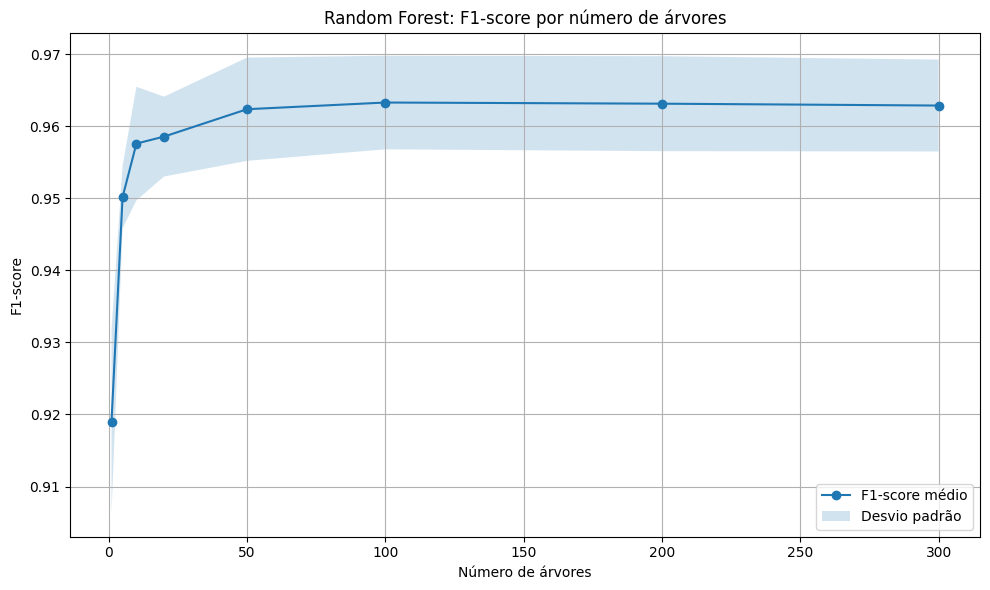

In [ ]:
# Visualizando os resultados por meio do gráfico
plt.figure(figsize=(10, 6))
plt.plot(n_trees, resultados_rf_mean, marker='o', label='F1-score médio')
plt.fill_between(n_trees,
                 [m - s for m, s in zip(resultados_rf_mean, resultados_rf_std)],
                 [m + s for m, s in zip(resultados_rf_mean, resultados_rf_std)],
                 alpha=0.2, label='Desvio padrão')
plt.title('Random Forest: F1-score por número de árvores')
plt.xlabel('Número de árvores')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Confirmando valores
for n, mean, std in zip(n_trees, resultados_rf_mean, resultados_rf_std):
    print(f'n_estimators={n}: F1 médio={mean:.4f}, desvio padrão={std:.4f}')

n_estimators=1: F1 médio=0.9190, desvio padrão=0.0128
n_estimators=5: F1 médio=0.9502, desvio padrão=0.0043
n_estimators=10: F1 médio=0.9576, desvio padrão=0.0079
n_estimators=20: F1 médio=0.9585, desvio padrão=0.0055
n_estimators=50: F1 médio=0.9623, desvio padrão=0.0072
n_estimators=100: F1 médio=0.9633, desvio padrão=0.0065
n_estimators=200: F1 médio=0.9631, desvio padrão=0.0066
n_estimators=300: F1 médio=0.9629, desvio padrão=0.0064


### Interpretando os resultados

> Com apenas 1 árvore, o modelo apresentou F1-score de 0.9190 e o maior desvio padrão entre todos os valores testados (0.0128), evidenciando alta instabilidade.

> Conforme o número de árvores aumenta, o F1-score cresce rapidamente até 50 árvores (0.9623), onde os ganhos se tornam mínimos. Isso mostra o efeito de retornos decrescentes: adicionar mais árvores continua melhorando marginalmente o modelo, mas o custo computacional aumenta sem benefício proporcional.

> A estabilidade melhora progressivamente, pois a votação entre mais árvores cancela os erros individuais de cada uma, tornando o resultado final menos dependente de variações nos dados de treino.

> Com base nesses resultados, `n_estimators=100` será utilizado como configuração final, por representar um bom equilíbrio entre performance, estabilidade e custo computacional.

### Criando o modelo final do Random Forest
> Utilizaremos `n_estimators=100` como hiperparâmetro final por representar o melhor equilíbrio entre performance, estabilidade e custo computacional.

In [ ]:
# Criando a pipeline final
pipeline_rf_final = Pipeline([
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

resultados_rf_final = cross_validate(
    pipeline_rf_final,
    X,
    y,
    cv=skf,
    scoring=scoring
)

pd.DataFrame(resultados_rf_final).mean()

,0
fit_time,2.939985
score_time,0.050590
test_accuracy,0.970395
test_precision,0.965670
test_recall,0.961036
test_f1,0.963270


### Interpretando os resultados finais

> O modelo final atingiu acurácia de aproximadamente 97,0%, precisão de 96,6%, recall de 96,1% e F1-score de 96,3%. Apresentou um equilíbrio muito bom entre precisão e recall, sem sacrificar uma métrica em favor da outra. Isso reflete a vantagem do método ensemble: ao combinar múltiplas árvores, o modelo reduz tanto o bias quanto a variância, resultando em previsões mais robustas e generalizáveis.

## Criando o modelo Gradient Tree Boosting
> O modelo treina árvores de forma sequencial, onde cada nova árvore é treinada para corrigir os erros cometidos pelo modelo anterior. Aqui o modelo evolui iterativamente. O número de iterações (`n_estimators`) será variado para analisar o efeito na performance e identificar possíveis sinais de overfitting com iterações excessivas.

In [ ]:
# Importando o modelo
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Montando o pipeline com iterações variadas
n_iterations = [10, 20, 50, 100, 150, 200, 300]
resultados_gb_mean = []
resultados_gb_std = []

for n in n_iterations:
    pipeline_gb = Pipeline([
        ('model', GradientBoostingClassifier(n_estimators=n, random_state=42))
    ])

    scores = cross_validate(
        pipeline_gb,
        X,
        y,
        cv=skf,
        scoring=scoring
    )

    resultados_gb_mean.append(scores['test_f1'].mean())
    resultados_gb_std.append(scores['test_f1'].std())

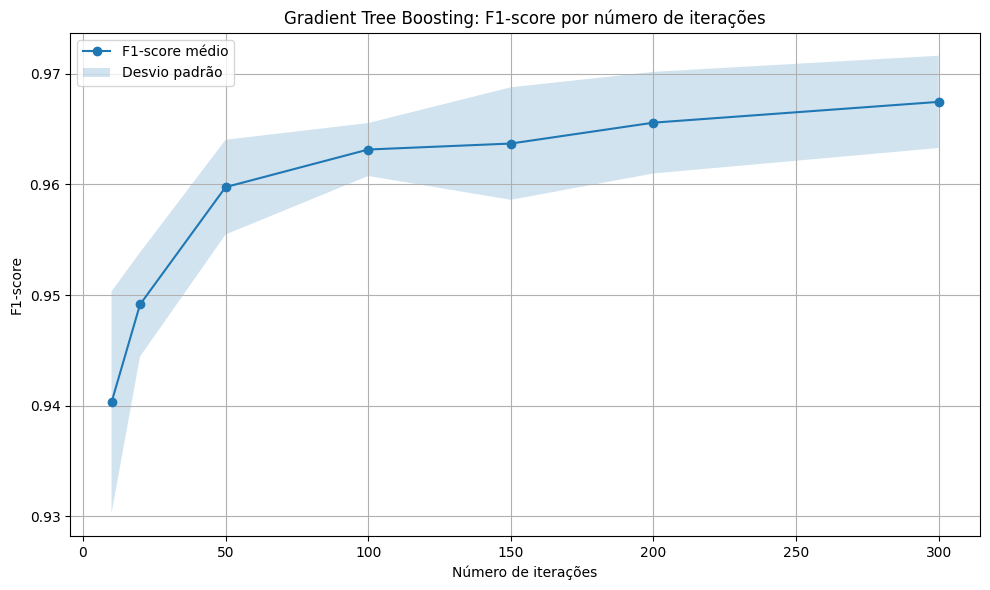

In [ ]:
# Visualizando os resultados

plt.figure(figsize=(10, 6))
plt.plot(n_iterations, resultados_gb_mean, marker='o', label='F1-score médio')
plt.fill_between(n_iterations,
                 [m - s for m, s in zip(resultados_gb_mean, resultados_gb_std)],
                 [m + s for m, s in zip(resultados_gb_mean, resultados_gb_std)],
                 alpha=0.2, label='Desvio padrão')
plt.title('Gradient Tree Boosting: F1-score por número de iterações')
plt.xlabel('Número de iterações')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Conferindo os valores
for n, mean, std in zip(n_iterations, resultados_gb_mean, resultados_gb_std):
    print(f'n_estimators={n}: F1 médio={mean:.4f}, desvio padrão={std:.4f}')

n_estimators=10: F1 médio=0.9403, desvio padrão=0.0100
n_estimators=20: F1 médio=0.9491, desvio padrão=0.0047
n_estimators=50: F1 médio=0.9598, desvio padrão=0.0043
n_estimators=100: F1 médio=0.9632, desvio padrão=0.0024
n_estimators=150: F1 médio=0.9637, desvio padrão=0.0051
n_estimators=200: F1 médio=0.9656, desvio padrão=0.0046
n_estimators=300: F1 médio=0.9675, desvio padrão=0.0042


### Interpretando os resultados

> O gráfico mostra que o F1-score cresce de forma consistente conforme o número de iterações aumenta, partindo de 0.9403 com 10 iterações e atingindo 0.9675 com 300 iterações. Não foram observados sinais claros de overfitting no intervalo testado. Isso ocorre porque o Gradient Boosting utiliza árvores rasas por padrão, o que limita a capacidade de cada árvore individual de memorizar o treino.

> O desvio padrão também diminui progressivamente com mais iterações, de 0.0100 com 10 iterações para valores em torno de 0.0024 a 0.0051 a partir de 100 iterações, indicando que o modelo se torna mais estável conforme o número de árvores aumenta.

> Apesar do F1-score continuar crescendo levemente até 300 iterações, o ganho entre 100 e 300 iterações é de apenas 0.0043, enquanto o custo computacional aumenta significativamente. Por isso, `n_estimators=100` será utilizado como configuração final, representando um bom equilíbrio entre performance e custo computacional.

### Criando o modelo final do Gradient Tree Boosting
> Escolhemos `n_estimators=100` como hiperparâmetro final por representar um bom equilíbrio entre performance e custo computacional.

In [ ]:
# Criando a pipeline final
pipeline_gb_final = Pipeline([
    ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

resultados_gb_final = cross_validate(
    pipeline_gb_final,
    X,
    y,
    cv=skf,
    scoring=scoring
)

pd.DataFrame(resultados_gb_final).mean()

,0
fit_time,8.005075
score_time,0.031191
test_accuracy,0.970012
test_precision,0.956896
test_recall,0.969587
test_f1,0.963165


### Interpretação dos resultados finais

> O modelo final atingiu acurácia de aproximadamente 97,0%, precisão de 95,7%, recall de 96,9% e F1-score de 96,3%. O modelo apresentou excelente equilíbrio entre precisão e recall, com ambas as métricas acima de 95%, indicando que o modelo acerta bem tanto na identificação de exoplanetas reais quanto na rejeição de falsos positivos.


## Comparação final entre os modelos do projeto

> Nesta seção, os resultados finais de todos os modelos são consolidados e comparados. A análise considera não apenas os valores das métricas obtidas, mas também aspectos como estabilidade, sensibilidade a hiperparâmetros e adequação ao problema. Com base nessa comparação, será indicado o modelo mais adequado para uso em um cenário prático.

> Relembrando os valores finais de cada modelo:

- Naive Bayes: acurácia 0.7935, precisão 0.7277, recall 0.7916, F1 0.7583
- Decision Tree: acurácia 0.9492, precisão 0.9194, recall 0.9587, F1 0.9386
- SVM: acurácia 0.9512, precisão 0.9217, recall 0.9610, F1 0.9409
- k-NN: acurácia 0.8958, precisão 0.8119, recall 0.9667, F1 0.8825
- Random Forest: acurácia 0.9704, precisão 0.9657, recall 0.9610, F1 0.9633
- Gradient Boosting: acurácia 0.9700, precisão 0.9569, recall 0.9696, F1 0.9632

In [ ]:
# Colocando os resultados finais em uma tabela
resultados_finais = {
    'Naive Bayes': {'accuracy': 0.9173, 'precision': 0.8462, 'recall': 0.9724, 'f1': 0.9049},
    'Decision Tree':      {'accuracy': 0.9492, 'precision': 0.9194, 'recall': 0.9587, 'f1': 0.9386},
    'SVM':                {'accuracy': 0.9512, 'precision': 0.9217, 'recall': 0.9610, 'f1': 0.9409},
    'k-NN':               {'accuracy': 0.8958, 'precision': 0.8119, 'recall': 0.9667, 'f1': 0.8825},
    'Random Forest':      {'accuracy': 0.9704, 'precision': 0.9657, 'recall': 0.9610, 'f1': 0.9633},
    'Gradient Boosting':  {'accuracy': 0.9700, 'precision': 0.9569, 'recall': 0.9696, 'f1': 0.9632},
}

dkoi_final = pd.DataFrame(resultados_finais).T
print(df_final)

                   accuracy  precision  recall      f1
Naive Bayes          0.7935     0.7277  0.7916  0.7583
Decision Tree        0.9492     0.9194  0.9587  0.9386
SVM                  0.9512     0.9217  0.9610  0.9409
k-NN                 0.8958     0.8119  0.9667  0.8825
Random Forest        0.9704     0.9657  0.9610  0.9633
Gradient Boosting    0.9700     0.9569  0.9696  0.9632


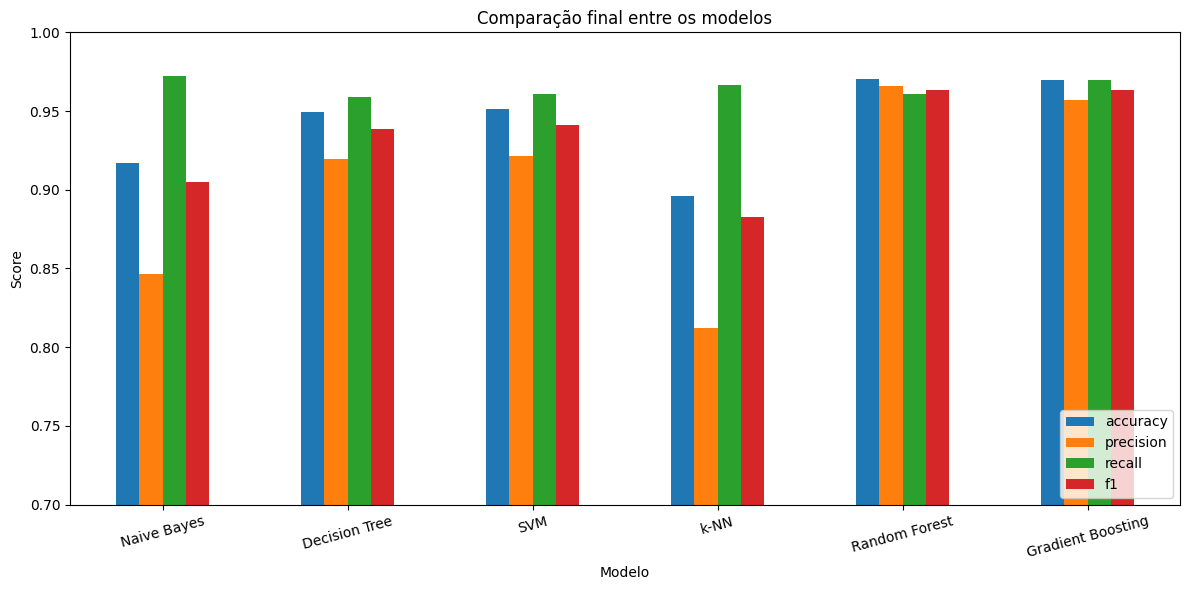

In [ ]:
# Construindo o gráfico de comparação
dkoi_final.plot(kind='bar', figsize=(12, 6))
plt.title('Comparação final entre os modelos')
plt.xlabel('Modelo')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretando os resultados finais

> O Naive Bayes, utilizado como baseline, apresentou o segundo menor F1-score (0.9049). Isso era esperado, pois o Naive Bayes assume independência entre as features, o que raramente é verdade em problemas reais. Seu valor está em servir como referência mínima: qualquer modelo que não supere o baseline não está aprendendo padrões relevantes.

> O k-NN apresentou o pior F1-score entre todos os modelos (0.8825), apesar de ter o maior recall (0.9667). Esse desequilíbrio entre precisão (0.8119) e recall indica que o modelo tende a classificar muitos exemplos como `CONFIRMED`, gerando falsos positivos. Como discutido anteriormente, isso pode ser explicado pela maldição da dimensionalidade: com 41 features, o conceito de proximidade perde eficácia.

> A Decision Tree e o SVM apresentaram desempenho muito similar, com F1-scores de 0.9386 e 0.9409 respectivamente. A Decision Tree tem como vantagem a interpretabilidade, permitindo visualizar as regras de decisão aprendidas. O SVM linear, por sua vez, apresentou desempenho ligeiramente superior e é eficaz em espaços de alta dimensão, como o deste problema com 41 features.

> O Random Forest e o Gradient Boosting foram os melhores modelos, com F1-scores praticamente idênticos de 0.9633 e 0.9632. Ambos apresentaram excelente equilíbrio entre precisão e recall, com todas as métricas acima de 95%.


## Modelo escolhido

> Concluindo o projeto, foi escolhido, para uso em um cenário prático, o **Random Forest** com `n_estimators=100`.

> Apesar do desempenho praticamente idêntico ao Gradient Boosting, o Random Forest apresenta duas vantagens importantes: suas árvores são treinadas de forma independente e em paralelo, tornando o treinamento significativamente mais rápido (temos um fit_time de aproximadamente 3 segundos contra aproximadamente 8 segundos do Gradient Boosting), e o modelo é menos sensível a hiperparâmetros, já que o desempenho se estabilizou rapidamente a partir de 50 árvores.

> Em um cenário prático onde eficiência computacional e robustez são valorizadas, essas características tornam **o Random Forest** a escolha mais adequada.